In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'seaborn'

In [1]:
from datasets import load_dataset

C:\Users\Lakshay\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
!pip install -q datasets

In [5]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [6]:
label_names = emotion_dataset['train'].features['label'].names

In [7]:
df_train = pd.DataFrame(
    {
        'text':train_text,
        'label':[label_names[i] for i in train_label]
    }
)
df_test = pd.DataFrame(
    {
        'text':test_text,
        'label':[label_names[i] for i in test_label]
    }
)


In [8]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [9]:
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [10]:
desc = df_train['label'].value_counts()

<Axes: xlabel='label', ylabel='count'>

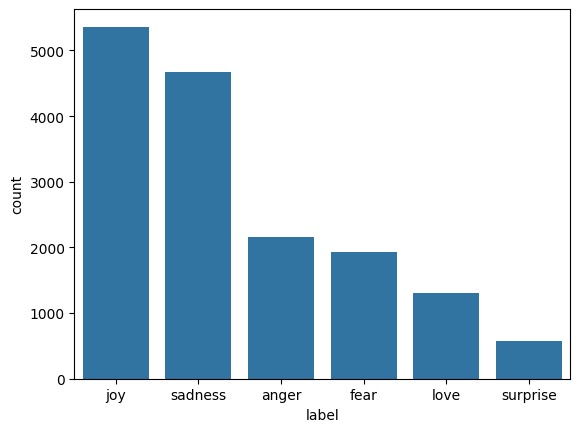

In [11]:
sns.countplot(x='label', data= df_train, order=desc.index)

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words =10000

tokenizer =  Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence, maxlen=50, padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequence, maxlen=50, padding='post', truncating='post')

train_labels = np.array(train_label);
test_labels = np.array(test_label);

num_classes = len(np.unique(train_labels));

print(f"Voocabulary Size : {len(tokenizer.word_index)}")
print(f"Max Sentence Length : {padded_train_sequence.shape[1]}")

Voocabulary Size : 15213
Max Sentence Length : 50


In [13]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes = np.unique(train_labels),
    y = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [14]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights = True
)

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential(
    [
        Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
        SimpleRNN(units =128, return_sequences=True),
        Dropout(0.5),
        SimpleRNN(units =64),
        Dropout(0.5),
        Dense(units=num_classes, activation='softmax')
    ]
)

rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [16]:
print("Train:", len(emotion_dataset["train"]))
print("Validation:", len(emotion_dataset["validation"]))
print("Test:", len(emotion_dataset["test"]))

print(emotion_dataset)
print(len(emotion_dataset["train"]["text"]))
print(len(emotion_dataset["validation"]["text"]))
print(len(emotion_dataset["test"]["text"]))

Train: 16000
Validation: 2000
Test: 2000
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
16000
2000
2000


In [17]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labels),
    epochs = 20,
    batch_size =32,
    validation_split=0.2,
    class_weight = class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN loss: {rnn_loss}")
print(f"RNN accuracy: {rnn_accuracy }")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 35s 59ms/step - accuracy: 0.1586 - loss: 2.0317 - val_accuracy: 0.2365 - val_loss: 1.7763
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - accuracy: 0.1417 - loss: 1.8907 - val_accuracy: 0.1460 - val_loss: 1.8094
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.1283 - loss: 1.8300 - val_accuracy: 0.2595 - val_loss: 1.7550
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.1382 - loss: 1.8093 - val_accuracy: 0.0440 - val_loss: 1.8525
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.1476 - loss: 1.8043 - val_accuracy: 0.0775 - val_loss: 1.7834
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.1366 - loss: 1.8015 - val_accuracy: 0.1115 - val_loss: 1.7956
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2595 - loss: 1.7550
RNN loss: 1.755004644393921
RNN accuracy: 0.25949999690055847


In [18]:
lstm_model = Sequential(
    [
        Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
        LSTM(units =128, return_sequences=True),
        Dropout(0.5),
        LSTM(units =64),
        Dropout(0.5),
        Dense(units=num_classes, activation='softmax')
    ]
)
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labels),
    epochs = 20,
    batch_size =32,
    class_weight = class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM loss: {lstm_loss}")
print(f"LSTM accuracy: {lstm_accuracy }")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 49s 92ms/step - accuracy: 0.1559 - loss: 1.7950 - val_accuracy: 0.0375 - val_loss: 1.7939
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 90ms/step - accuracy: 0.1402 - loss: 1.7930 - val_accuracy: 0.2905 - val_loss: 1.7803
Epoch 3/20
204/500 ━━━━━━━━━━━━━━━━━━━━ 26s 91ms/step - accuracy: 0.1621 - loss: 1.7854

In [ ]:
gru_model = Sequential(
    [
        Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
        LSTM(units =128, return_sequences=True),
        Dropout(0.5),
        LSTM(units =64),
        Dropout(0.5),
        Dense(units=num_classes, activation='softmax')
    ]
)
gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labels),
    epochs = 20,
    batch_size =32,
    validation_split=0.2,
    class_weight = class_weight_dict,
    callbacks=[early_stopping]
)
gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU loss: {gru_loss}")
print(f"GRU accuracy: {gru_accuracy }")

In [ ]:
result_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM','GRU'],
    'Test Loss' : [rnn_loss, lstm_loss, gru_loss],
    'Accuracy' : [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Accuracy',ascending=False)
result_df

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout
BiGRU = Sequential([
  Embedding(input_dim = max_words, output_dim = 300, input_length = 50),
  Bidirectional(GRU(128, return_sequences=True)),
        Dropout(0.5),
        Bidirectional(GRU(64)),
        Dropout(0.5),
        Dense(units=num_classes, activation='softmax')
])
BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

In [ ]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labels),
    epochs = 20,
    batch_size =32,
    validation_split=0.2,
    class_weight = class_weight_dict,
    callbacks=[early_stopping]
)
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"GRU loss: {BiGRU_loss}")
print(f"GRU accuracy: {BiGRU_accuracy }")

In [ ]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.prdeict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions), annot=True, fmt = 'd', cmap='Blues', xticklabels= label_names, yticklabels=label_names)

In [ ]:
sample_texts = [
    "I am so happy and excited about the wonderful news!",
    "I feel really sad and lonely today.",
    "I am extremely angry about what happened.",
    "I am scared and worried about the situation.",
    "I absolutely love spending time with my family."
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sampple_sequences, maxlen=50, padding='post', truncating='post')
